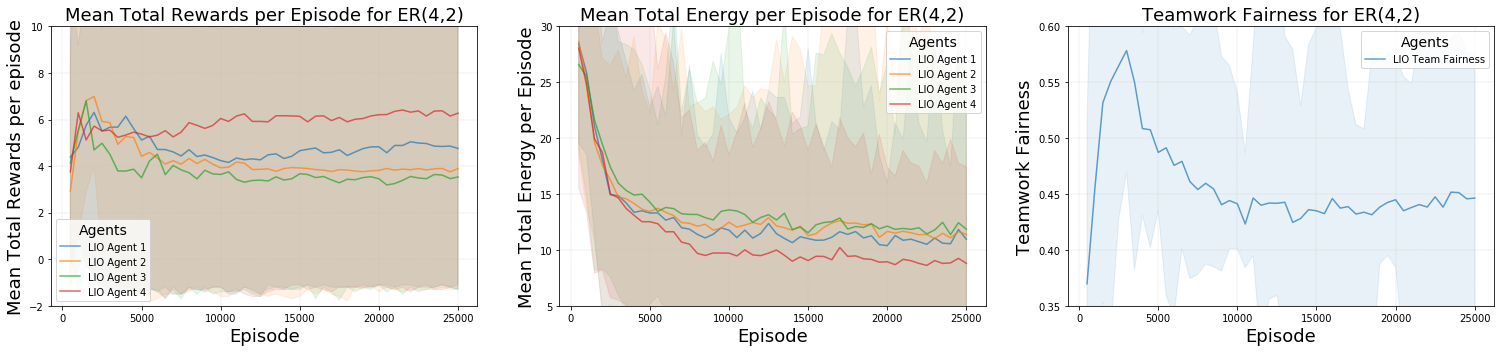

In [86]:
# Overall performance comparison of LIO in the ER(4,2) environment with all normal agents
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data 
df_all = []
for i in range(20):
    # Load the data
    df = pd.read_csv(f'lio/results/er{i+1}/er_lio_4_2/log.csv')
    
    # IMPORTANT: Clean column names by stripping whitespace
    df.columns = [col.strip() for col in df.columns]
    # print out the column names in your first DF
 
    # Divide metrics by 10 to get the mean of each evaluation run
    for agent_id in range(1, 5):  # For agents 1-4
        # Divide reward metrics by 10
        df[f'A{agent_id}_reward_total'] = df[f'A{agent_id}_reward_total'] / 10.0
        df[f'A{agent_id}_reward_env'] = df[f'A{agent_id}_reward_env'] / 10.0
        
        # Divide energy metrics by 10
        df[f'A{agent_id}_total_energy'] = df[f'A{agent_id}_total_energy'] / 10.0

    # Add to list
    df_all.append(df)

# Find minimum length
min_length = min([len(df) for df in df_all])
t = df_all[0]['episode'].values[:min_length]

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))
# Colors for each agent
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Process rewards data for first plot - now sum three agents


# Plot 1: Total Rewards
# Plot individual agent rewards to see the difference
for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_rewards = []
    for df in df_all:
        agent_rewards.append(df[f'A{agent_id}_reward_total'].values[:min_length])
    agent_signal = np.vstack(agent_rewards)

    minsr = np.min(agent_signal, axis=0)
    maxsr = np.max(agent_signal, axis=0)
    meansr = np.mean(agent_signal, axis=0)
    ax1.fill_between(t, minsr, maxsr, alpha=0.1, color=color)
    ax1.plot(t, meansr, color=color, 
             label=f'LIO Agent {agent_id}',
             linestyle='-', alpha=0.7)

ax1.grid(color='silver', linestyle='--', linewidth=0.3)
ax1.set_xlabel('Episode', fontsize=18)
ax1.set_ylabel('Mean Total Rewards per episode', fontsize=18)
ax1.set_title('Mean Total Rewards per Episode for ER(4,2)', fontsize=18)
ax1.legend(title='Agents', title_fontsize=14, loc='best')


# Process collective energy data for second plot

# Plot 2: Total Energy
# Plot individual agent energy to see the difference

for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_energy = []
    for df in df_all:
        agent_energy.append(df[f'A{agent_id}_total_energy'].values[:min_length])
    agent_signal = np.vstack(agent_energy)

    minse = np.min(agent_signal, axis=0)
    maxse = np.max(agent_signal, axis=0)
    meanse = np.mean(agent_signal, axis=0)
    ax2.fill_between(t, minse, maxse, alpha=0.1, color=color)
    ax2.plot(t, meanse, color=color, 
             label=f'LIO Agent {agent_id}',
             linestyle='-', alpha=0.7)
    
ax2.grid(color='silver', linestyle='--', linewidth=0.3)    
ax2.set_xlabel('Episode', fontsize=18)
ax2.set_ylabel('Mean Total Energy per Episode', fontsize=18)
ax2.set_title('Mean Total Energy per Episode for ER(4,2)', fontsize=18)
ax2.legend(title='Agents', title_fontsize=14, loc='best')


# Process team fairness data for third plot

# Plot 3: Team Fairness

team_series = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all ]
signal = np.vstack(team_series)
min_f = signal.min(axis=0)
max_f = signal.max(axis=0)
mean_f = signal.mean(axis=0)
ax3.fill_between(t, min_f, max_f, alpha=0.1, color='tab:blue')
ax3.plot(t, mean_f, color='tab:blue',
             label='LIO Team Fairness',
             linestyle='-', alpha=0.7)
    
ax3.grid(color='silver', linestyle='--', linewidth=0.3)
ax3.set_xlabel('Episode', fontsize=18)
ax3.set_ylabel('Teamwork Fairness', fontsize=18)
ax3.set_title('Teamwork Fairness for ER(4,2)', fontsize=18)
ax3.legend(title='Agents', title_fontsize=14, loc='best')


# Adjust y-axis limits for better visualization
ax1.set_ylim(-2, 10)  # For total rewards
ax2.set_ylim(5, 30)     # For total energy
ax3.set_ylim(0.35, 0.6)     # For Teamwork Fairness
plt.tight_layout()
plt.show()

# Save the performance plot with normal agent
fig.savefig('lio_normal_ER42_overall.png', dpi=300)

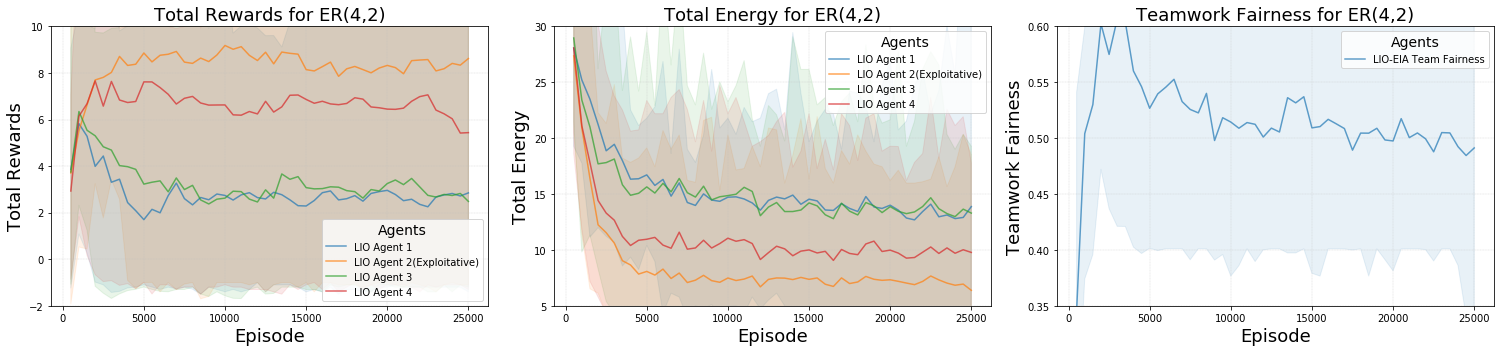

In [87]:
# Overall performance comparison of LIO in the ER(4,2) environment with exploitative 2nd agent 
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data 
df_all = []
for i in range(20):
    # Load the data
    df = pd.read_csv(f'lio/results/er{i+1}/er_attack_4_2/log.csv')
    
    # IMPORTANT: Clean column names by stripping whitespace
    df.columns = [col.strip() for col in df.columns]
    # Divide metrics by 10 to get the mean of each evaluation run
    for agent_id in range(1, 5):  # For agents 1-4
        # Divide reward metrics by 10
        df[f'A{agent_id}_reward_total'] = df[f'A{agent_id}_reward_total'] / 10.0
        df[f'A{agent_id}_reward_env'] = df[f'A{agent_id}_reward_env'] / 10.0
        
        # Divide energy metrics by 10
        df[f'A{agent_id}_total_energy'] = df[f'A{agent_id}_total_energy'] / 10.0

    # Add to list
    df_all.append(df)
# Find minimum length
min_length = min([len(df) for df in df_all])
t = df_all[0]['episode'].values[:min_length]

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))
# Colors for each agent
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Process rewards data for first plot - now sum three agents


# Plot 1: Total Rewards
# Plot individual agent rewards to see the difference
for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_rewards = []
    for df in df_all:
        agent_rewards.append(df[f'A{agent_id}_reward_total'].values[:min_length])
    agent_signal = np.vstack(agent_rewards)

    minsr = np.min(agent_signal, axis=0)
    maxsr = np.max(agent_signal, axis=0)
    meansr = np.mean(agent_signal, axis=0)
    ax1.fill_between(t, minsr, maxsr, alpha=0.1, color=color)
    ax1.plot(t, meansr, color=color, 
             label=f'LIO Agent {agent_id}{"(Exploitative)" if agent_id==2 else ""}',
             linestyle='-', alpha=0.7)

ax1.grid(color='silver', linestyle='--', linewidth=0.3)
ax1.set_xlabel('Episode', fontsize=18)
ax1.set_ylabel('Total Rewards', fontsize=18)
ax1.set_title('Total Rewards for ER(4,2)', fontsize=18)
ax1.legend(title='Agents', title_fontsize=14, loc='best')


# Process collective energy data for second plot

# Plot 2: Total Energy
# Plot individual agent energy to see the difference

for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_energy = []
    for df in df_all:
        agent_energy.append(df[f'A{agent_id}_total_energy'].values[:min_length])
    agent_signal = np.vstack(agent_energy)

    minse = np.min(agent_signal, axis=0)
    maxse = np.max(agent_signal, axis=0)
    meanse = np.mean(agent_signal, axis=0)
    ax2.fill_between(t, minse, maxse, alpha=0.1, color=color)
    ax2.plot(t, meanse, color=color, 
             label=f'LIO Agent {agent_id}{"(Exploitative)" if agent_id==2 else ""}',
             linestyle='-', alpha=0.7)
    
ax2.grid(color='silver', linestyle='--', linewidth=0.3)    
ax2.set_xlabel('Episode', fontsize=18)
ax2.set_ylabel('Total Energy', fontsize=18)
ax2.set_title('Total Energy for ER(4,2)', fontsize=18)
ax2.legend(title='Agents', title_fontsize=14, loc='best')


# Process team fairness data for third plot

# Plot 3: Team Fairness

team_series = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all ]
signal = np.vstack(team_series)
min_f = signal.min(axis=0)
max_f = signal.max(axis=0)
mean_f = signal.mean(axis=0)
ax3.fill_between(t, min_f, max_f, alpha=0.1, color='tab:blue')
ax3.plot(t, mean_f, color='tab:blue',
             label='LIO-EIA Team Fairness',
             linestyle='-', alpha=0.7)
    
ax3.grid(color='silver', linestyle='--', linewidth=0.3)
ax3.set_xlabel('Episode', fontsize=18)
ax3.set_ylabel('Teamwork Fairness', fontsize=18)
ax3.set_title('Teamwork Fairness for ER(4,2)', fontsize=18)
ax3.legend(title='Agents', title_fontsize=14, loc='best')


# Adjust y-axis limits for better visualization
ax1.set_ylim(-2, 10)  # For total rewards
ax2.set_ylim(5, 30)     # For total energy
ax3.set_ylim(0.35, 0.6)     # For Teamwork Fairness
plt.tight_layout()
plt.show()



# Save the performance plot with exploitative agent
fig.savefig('lio_eia_2ndexploitative_ER42_overall.png', dpi=300)

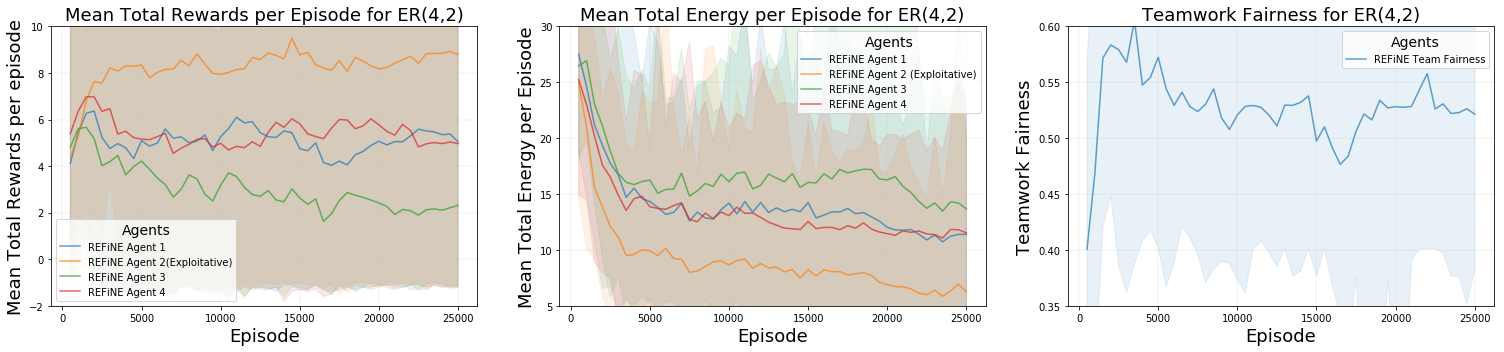

In [88]:
# Overall performance comparison of REFiNE in the ER(4,2) environment with exploitative 2nd agent
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data 
df_all = []
for i in range(20):
    # Load the data
    df = pd.read_csv(f'lio/results/er{i+1}/er_REFiNE_attack_4_2/log.csv')
    
    # IMPORTANT: Clean column names by stripping whitespace
    df.columns = [col.strip() for col in df.columns]
    # Divide metrics by 10 to get the mean of each evaluation run
    for agent_id in range(1, 5):  # For agents 1-4
        # Divide reward metrics by 10
        df[f'A{agent_id}_reward_total'] = df[f'A{agent_id}_reward_total'] / 10.0
        df[f'A{agent_id}_reward_env'] = df[f'A{agent_id}_reward_env'] / 10.0
        
        # Divide energy metrics by 10
        df[f'A{agent_id}_total_energy'] = df[f'A{agent_id}_total_energy'] / 10.0

    # Add to list
    df_all.append(df)

# Find minimum length
min_length = min([len(df) for df in df_all])
t = df_all[0]['episode'].values[:min_length]

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))
# Colors for each agent
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

# Process rewards data for first plot - now sum three agents


# Plot 1: Total Rewards
# Plot individual agent rewards to see the difference
for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_rewards = []
    for df in df_all:
        agent_rewards.append(df[f'A{agent_id}_reward_total'].values[:min_length])
    agent_signal = np.vstack(agent_rewards)

    minsr = np.min(agent_signal, axis=0)
    maxsr = np.max(agent_signal, axis=0)
    meansr = np.mean(agent_signal, axis=0)
    ax1.fill_between(t, minsr, maxsr, alpha=0.1, color=color)
    ax1.plot(t, meansr, color=color, 
             label=f'REFiNE Agent {agent_id}{"(Exploitative)" if agent_id==2 else ""}',
             linestyle='-', alpha=0.7)

ax1.grid(color='silver', linestyle='--', linewidth=0.3)
ax1.set_xlabel('Episode', fontsize=18)
ax1.set_ylabel('Mean Total Rewards per episode', fontsize=18)
ax1.set_title('Mean Total Rewards per Episode for ER(4,2)', fontsize=18)
ax1.legend(title='Agents', title_fontsize=14, loc='best')


# Process collective energy data for second plot

# Plot 2: Total Energy
# Plot individual agent energy to see the difference

for agent_id, color in zip([1,2,3,4], colors):  # Plot each agent separately
    agent_energy = []
    for df in df_all:
        agent_energy.append(df[f'A{agent_id}_total_energy'].values[:min_length])
    agent_signal = np.vstack(agent_energy)

    minse = np.min(agent_signal, axis=0)
    maxse = np.max(agent_signal, axis=0)
    meanse = np.mean(agent_signal, axis=0)
    ax2.fill_between(t, minse, maxse, alpha=0.1, color=color)
    ax2.plot(t, meanse, color=color, 
             label=f'REFiNE Agent {agent_id} {"(Exploitative)" if agent_id==2 else ""}',
             linestyle='-', alpha=0.7)
    
ax2.grid(color='silver', linestyle='--', linewidth=0.3)    
ax2.set_xlabel('Episode', fontsize=18)
ax2.set_ylabel('Mean Total Energy per Episode', fontsize=18)
ax2.set_title('Mean Total Energy per Episode for ER(4,2)', fontsize=18)
ax2.legend(title='Agents', title_fontsize=14, loc='best')


# Process team fairness data for third plot

# Plot 3: Team Fairness

team_series = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all ]
signal = np.vstack(team_series)
min_f = signal.min(axis=0)
max_f = signal.max(axis=0)
mean_f = signal.mean(axis=0)
ax3.fill_between(t, min_f, max_f, alpha=0.1, color='tab:blue')
ax3.plot(t, mean_f, color='tab:blue',
             label='REFiNE Team Fairness',
             linestyle='-', alpha=0.7)
    
ax3.grid(color='silver', linestyle='--', linewidth=0.3)
ax3.set_xlabel('Episode', fontsize=18)
ax3.set_ylabel('Teamwork Fairness', fontsize=18)
ax3.set_title('Teamwork Fairness for ER(4,2)', fontsize=18)
ax3.legend(title='Agents', title_fontsize=14, loc='best')


# Adjust y-axis limits for better visualization
ax1.set_ylim(-2, 10)  # For total rewards
ax2.set_ylim(5, 30)     # For total energy
ax3.set_ylim(0.35, 0.6)     # For Teamwork Fairness
plt.tight_layout()
plt.show()


# Save the performance plot with exploitative agent
fig.savefig('REFiNE_exploitative_ER42_overall.png', dpi=300)

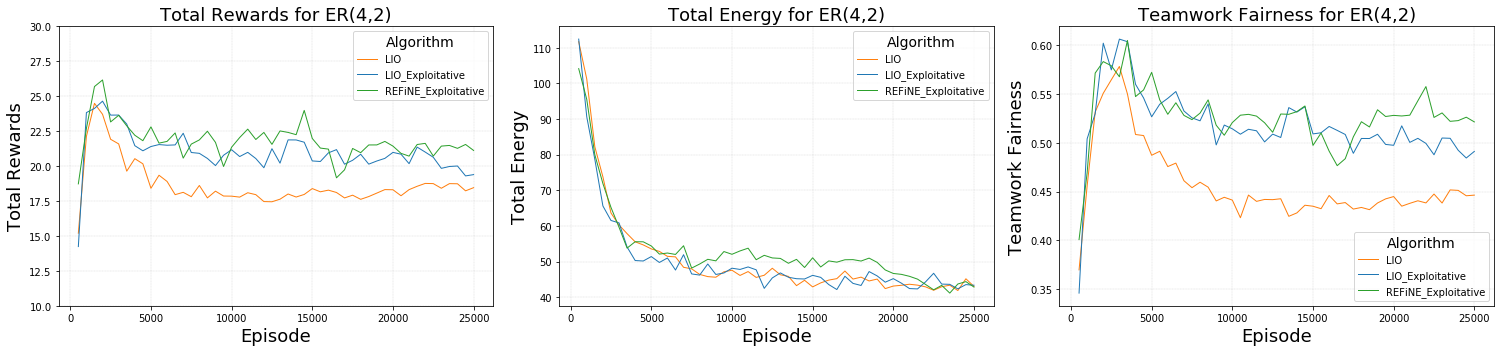

In [91]:
# Overall performance comparison of LIO, its exploitative case, and LIO-Defense in the ER(4,2) environment 
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_all_LIO = []
df_all_LIO_Exploitative = []
df_all_REFiNE_Exploitative = []

for i in range(20):
# Load the data
    df_LIO = pd.read_csv(f'lio/results/er{i+1}/er_lio_4_2/log.csv')
    df_LIO_Exploitative = pd.read_csv(f'lio/results/er{i+1}/er_attack_4_2/log.csv')
    df_REFiNE_Exploitative = pd.read_csv(f'lio/results/er{i+1}/er_REFiNE_attack_4_2/log.csv')
    
    # IMPORTANT: Clean column names by stripping whitespace
    df_LIO.columns = [col.strip() for col in df_LIO.columns]
    df_LIO_Exploitative.columns = [col.strip() for col in df_LIO_Exploitative.columns]
    df_REFiNE_Exploitative.columns = [col.strip() for col in df_REFiNE_Exploitative.columns]

    # Divide metrics by 10 to get the mean of each evaluation run
    for agent_id in range(1, 5):  # For agents 1-4
        # Divide reward metrics by 10
        df_LIO[f'A{agent_id}_reward_total'] = df_LIO[f'A{agent_id}_reward_total'] / 10.0
        df_LIO[f'A{agent_id}_reward_env'] = df_LIO[f'A{agent_id}_reward_env'] / 10.0
        df_LIO_Exploitative[f'A{agent_id}_reward_total'] = df_LIO_Exploitative[f'A{agent_id}_reward_total'] / 10.0
        df_LIO_Exploitative[f'A{agent_id}_reward_env'] = df_LIO_Exploitative[f'A{agent_id}_reward_env'] / 10.0
        df_REFiNE_Exploitative[f'A{agent_id}_reward_total'] = df_REFiNE_Exploitative[f'A{agent_id}_reward_total'] / 10.0
        df_REFiNE_Exploitative[f'A{agent_id}_reward_env'] = df_REFiNE_Exploitative[f'A{agent_id}_reward_env'] / 10.0
        
        # Divide energy metrics by 10
        df_LIO[f'A{agent_id}_total_energy'] = df_LIO[f'A{agent_id}_total_energy'] / 10.0
        df_LIO_Exploitative[f'A{agent_id}_total_energy'] = df_LIO_Exploitative[f'A{agent_id}_total_energy'] / 10.0
        df_REFiNE_Exploitative[f'A{agent_id}_total_energy'] = df_REFiNE_Exploitative[f'A{agent_id}_total_energy'] / 10.0

    # Add to list
    df_all_LIO.append(df_LIO)
    df_all_LIO_Exploitative.append(df_LIO_Exploitative)
    df_all_REFiNE_Exploitative.append(df_REFiNE_Exploitative)
    

    
# Find minimum length across all dataframes
min_length = min([len(df) for df in df_all_LIO + df_all_LIO_Exploitative + df_all_REFiNE_Exploitative])
t = df_all_LIO[0]['episode'].values[:min_length]

# Create three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 5))

# Process rewards data for first plot: collective return
signal1 = np.zeros((len(df_all_LIO), min_length))  # LIO
signal2 = np.zeros((len(df_all_LIO_Exploitative), min_length))  # LIO_Exploitative
signal3 = np.zeros((len(df_all_REFiNE_Exploitative), min_length))  # REFiNE_Exploitative

# Fill arrays with data from each run
for idx, df in enumerate(df_all_LIO):
    signal1[idx] = (df['A1_reward_total'].values[:min_length] + 
                   df['A2_reward_total'].values[:min_length] + 
                   df['A3_reward_total'].values[:min_length]
                   + df['A4_reward_total'].values[:min_length])

for idx, df in enumerate(df_all_LIO_Exploitative):
    signal2[idx] = (df['A1_reward_total'].values[:min_length] + 
                   df['A2_reward_total'].values[:min_length] + 
                   df['A3_reward_total'].values[:min_length]
                   + df['A4_reward_total'].values[:min_length])
    
for idx, df in enumerate(df_all_REFiNE_Exploitative):
    signal3[idx] = (df['A1_reward_total'].values[:min_length] + 
                   df['A2_reward_total'].values[:min_length] + 
                   df['A3_reward_total'].values[:min_length]
                   + df['A4_reward_total'].values[:min_length])

# Plot 1: Total Rewards 
mins1 = np.min(signal1, axis=0)
maxs1 = np.max(signal1, axis=0)
means1 = np.mean(signal1, axis=0)

mins2 = np.min(signal2, axis=0)
maxs2 = np.max(signal2, axis=0)
means2 = np.mean(signal2, axis=0)

mins3 = np.min(signal3, axis=0)
maxs3 = np.max(signal3, axis=0)
means3 = np.mean(signal3, axis=0)



ax1.plot(t, means1, color='tab:orange', label='LIO', linewidth=1)

ax1.plot(t, means2, color='tab:blue', label='LIO_Exploitative', linewidth=1)

ax1.plot(t, means3, color='tab:green', label='REFiNE_Exploitative', linewidth=1)



ax1.grid(color='silver', linestyle='--', linewidth=0.3)
ax1.set_xlabel('Episode', fontsize=18)
ax1.set_ylabel('Total Rewards', fontsize=18)
ax1.set_title('Total Rewards for ER(4,2)', fontsize=18)
ax1.legend(title='Algorithm', title_fontsize=14, loc='best')
ax1.set_ylim(10, 30)

# Process collective energy data for second plot
energy1 = np.zeros((len(df_all_LIO), min_length)) # LIO
energy2 = np.zeros((len(df_all_LIO_Exploitative), min_length)) # LIO_Exploitative
energy3 = np.zeros((len(df_all_REFiNE_Exploitative), min_length)) #     

for idx, df in enumerate(df_all_LIO):
    energy1[idx] = (df['A1_total_energy'].values[:min_length] + 
                   df['A2_total_energy'].values[:min_length] +
                   df['A3_total_energy'].values[:min_length]
                   + df['A4_total_energy'].values[:min_length])

for idx, df in enumerate(df_all_LIO_Exploitative):
    energy2[idx] = (df['A1_total_energy'].values[:min_length] + 
                   df['A2_total_energy'].values[:min_length] +
                   df['A3_total_energy'].values[:min_length]
                   + df['A4_total_energy'].values[:min_length])
    
for idx, df in enumerate(df_all_REFiNE_Exploitative):
    energy3[idx] = (df['A1_total_energy'].values[:min_length] + 
                   df['A2_total_energy'].values[:min_length] +
                   df['A3_total_energy'].values[:min_length]
                   + df['A4_total_energy'].values[:min_length])    


# Plot 2: Total Energy 
mins_e1 = np.min(energy1, axis=0)
maxs_e1 = np.max(energy1, axis=0)
means_e1 = np.mean(energy1, axis=0)

mins_e2 = np.min(energy2, axis=0)
maxs_e2 = np.max(energy2, axis=0)
means_e2 = np.mean(energy2, axis=0)

mins_e3 = np.min(energy3, axis=0)
maxs_e3 = np.max(energy3, axis=0)   
means_e3 = np.mean(energy3, axis=0)


ax2.plot(t, means_e1, color='tab:orange', label='LIO', linewidth=1)

ax2.plot(t, means_e2, color='tab:blue', label='LIO_Exploitative', linewidth=1)

ax2.plot(t, means_e3, color='tab:green', label='REFiNE_Exploitative', linewidth=1)


ax2.grid(color='silver', linestyle='--', linewidth=0.3)
ax2.set_xlabel('Episode', fontsize=18)
ax2.set_ylabel('Total Energy', fontsize=18)
ax2.set_title('Total Energy for ER(4,2)', fontsize=18)
ax2.legend(title='Algorithm', title_fontsize=14, loc='best')

# Process teamwork fairness for third plot
team1 = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all_LIO ]
team2 = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all_LIO_Exploitative ]
team3 = [ df['A1_teamwork_fairness'].values[:min_length] for df in df_all_REFiNE_Exploitative ]

signalf1 = np.vstack(team1)
signalf2 = np.vstack(team2)
signalf3 = np.vstack(team3)




    
# Plot 3: Teamwork Fairness
mins_f1 = np.min(signalf1, axis=0)
maxs_f1 = np.max(signalf1, axis=0)
means_f1 = np.mean(signalf1, axis=0)

mins_f2 = np.min(signalf2, axis=0)
maxs_f2 = np.max(signalf2, axis=0)
means_f2 = np.mean(signalf2, axis=0)

mins_f3 = np.min(signalf3, axis=0)
maxs_f3 = np.max(signalf3, axis=0)
means_f3 = np.mean(signalf3, axis=0)




ax3.plot(t, means_f1, color='tab:orange', label='LIO', linewidth=1)

ax3.plot(t, means_f2, color='tab:blue', label='LIO_Exploitative', linewidth=1)

ax3.plot(t, means_f3, color='tab:green', label='REFiNE_Exploitative', linewidth=1)

ax3.grid(color='silver', linestyle='--', linewidth=0.3)
ax3.set_xlabel('Episode', fontsize=18)
ax3.set_ylabel('Teamwork Fairness', fontsize=18)
ax3.set_title('Teamwork Fairness for ER(4,2)', fontsize=18)
ax3.legend(title='Algorithm', title_fontsize=14, loc='best')

plt.tight_layout()
plt.show()


# Save figure
fig.savefig('Overall_performance_REFiNE_Exploitative_ER42.png', dpi=300)